In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

In [42]:
data_path=r"/content/hotel_bookings (1).csv"
df=pd.read_csv(data_path)
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [40]:
df.info()
print("\n--- Descriptive Statistics ---")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51390 entries, 0 to 51389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           51390 non-null  object 
 1   is_canceled                     51390 non-null  int64  
 2   lead_time                       51390 non-null  int64  
 3   arrival_date_year               51390 non-null  int64  
 4   arrival_date_month              51390 non-null  object 
 5   arrival_date_week_number        51390 non-null  int64  
 6   arrival_date_day_of_month       51390 non-null  int64  
 7   stays_in_weekend_nights         51390 non-null  int64  
 8   stays_in_week_nights            51390 non-null  int64  
 9   adults                          51390 non-null  int64  
 10  children                        51386 non-null  float64
 11  babies                          51390 non-null  int64  
 12  meal                            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,51390.000000,51390.000000,51390.000000,51390.000000,51390.000000,51390.000000,51390.000000,51390.000000,51386.000000,51390.000000,51390.000000,51390.000000,51390.000000,51390.000000,42526.000000,3359.000000,51390.000000,51390.000000,51389.000000,51389.000000
mean,0.334326,90.248395,2015.970889,27.226114,15.794999,1.107356,2.925628,1.857696,0.115226,0.011948,0.034598,0.079296,0.114166,0.260226,166.758477,228.532004,2.577778,93.995650,0.110432,0.554146
std,0.471759,93.587831,0.735646,13.941423,8.800665,1.112559,2.316884,0.651861,0.424297,0.117928,0.182762,1.179537,0.886714,0.695096,116.978696,130.298336,17.360154,60.987909,0.318603,0.787426
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,13.000000,2015.000000,15.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,130.000000,0.000000,56.000000,0.000000,0.000000
50%,0.000000,61.000000,2016.000000,29.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,79.000000,0.000000,0.000000
75%,1.000000,141.000000,2017.000000,38.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,308.000000,0.000000,116.745000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,30.000000,20.000000,535.000000,543.000000,259.000000,5400.000000,8.000000,5.000000


In [41]:
print(df.isnull().sum())

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             478
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              8864
company                           48031


In [42]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 11031


In [ ]:
    ###  Data preprocessing ###
X = df[['lead_time']].values
y = df['adr'].values

# Perform train-test split (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape (samples, features): {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape (samples, features): (95512, 1)
y_train shape: (95512,)
X_test shape:  (23878, 1)
y_test shape:  (23878,)


In [ ]:
### model Tranning ###
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


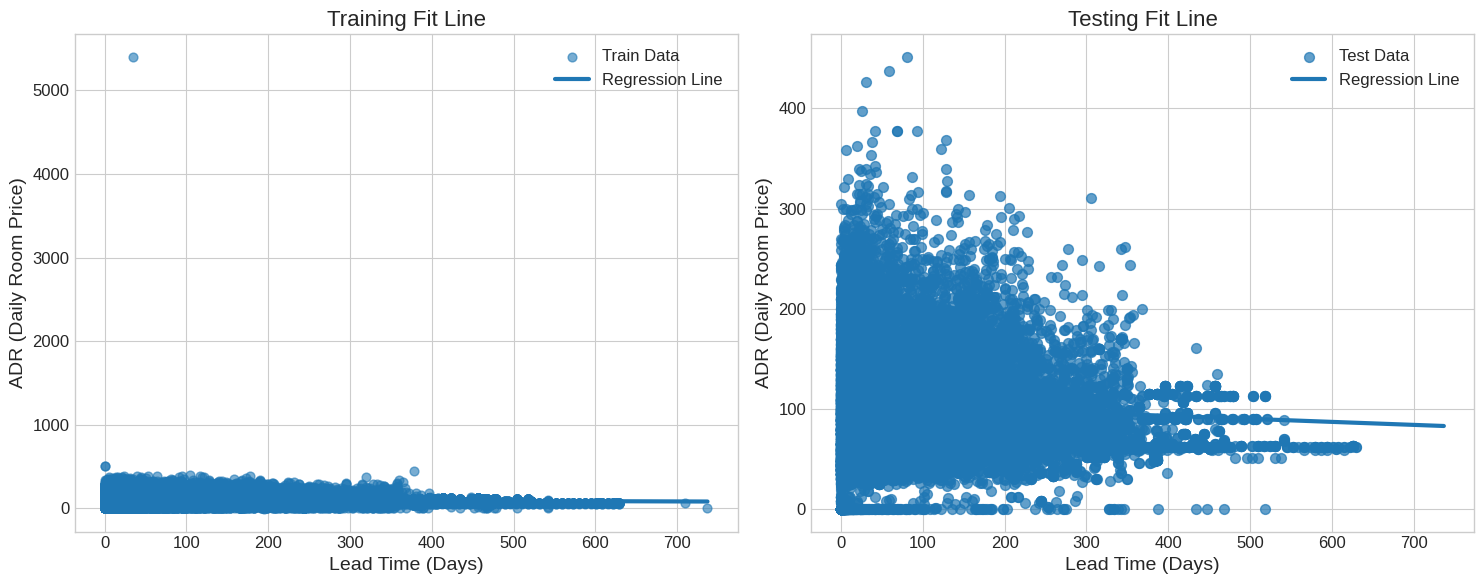

In [ ]:
###Visualizing the Regression Line ###
X_line = np.linspace(df['lead_time'].min(), df['lead_time'].max(), 100).reshape(-1, 1)
y_line_pred = model.predict(X_line)

# Plot Training data vs Regression Line
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, s=40, label='Train Data')
plt.plot(X_line, y_line_pred, linewidth=3, label='Regression Line')

plt.title('Training Fit Line')
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR (Daily Room Price)')
plt.legend()


# Plot Test data vs Regression Line
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, alpha=0.7, s=50, label='Test Data')
plt.plot(X_line, y_line_pred, linewidth=3, label='Regression Line')

plt.title('Testing Fit Line')
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR (Daily Room Price)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
## logistic  ##
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

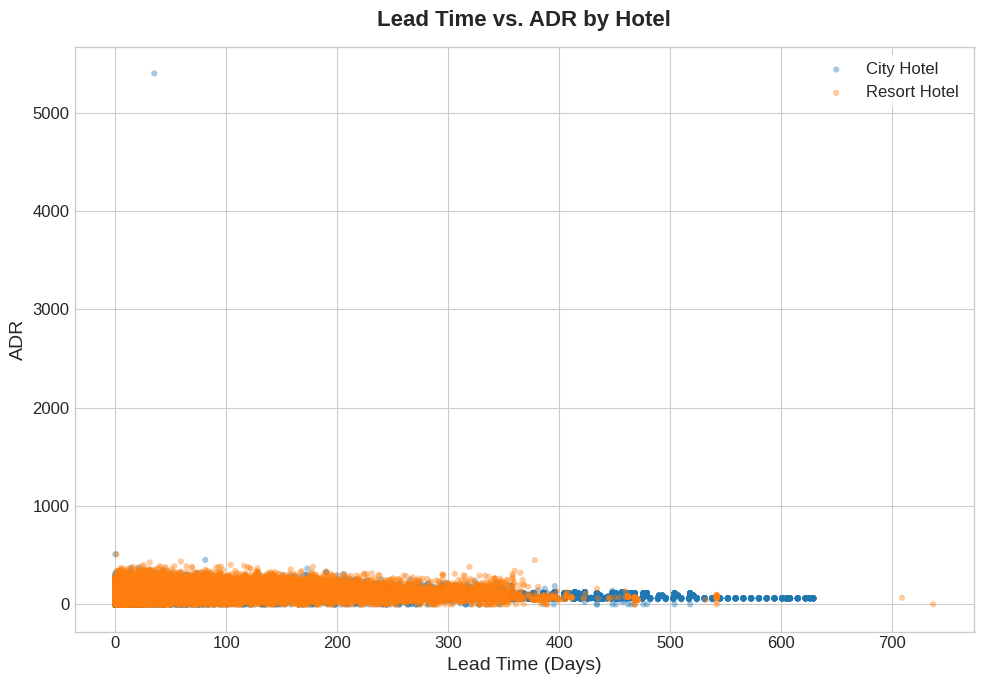

In [ ]:
plt.figure(figsize=(10, 7))

for hotel, group in df.groupby('hotel'):
    plt.scatter(
        group['lead_time'],
        group['adr'],
        label=hotel,
        alpha=0.4,
        edgecolors='none',
        s=20
    )

plt.title('Lead Time vs. ADR by Hotel', fontweight='bold', pad=15)
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR')
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

In [ ]:
###Data Preprocessing###
X = df[['lead_time', 'adr']].values
y = df['is_canceled'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_train_scaled.shape)

print(np.round(X_train_scaled.mean(axis=0), 4))
print(np.round(X_train_scaled.std(axis=0), 4))

(95512, 2)
(95512, 2)
[0. 0.]
[1. 1.]


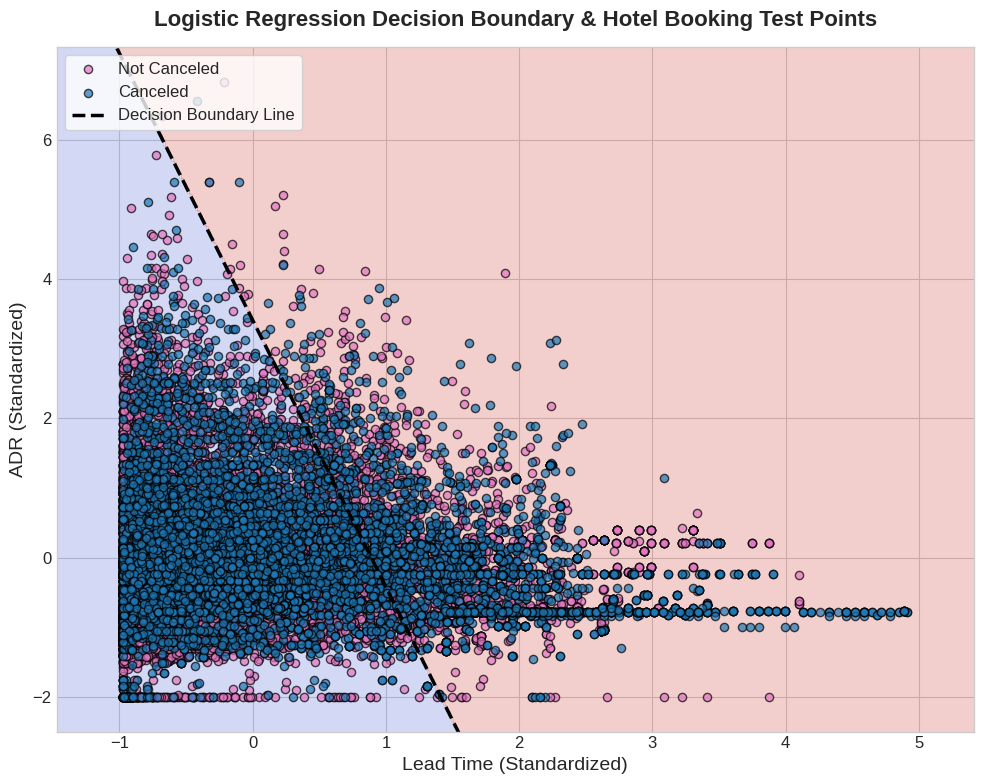

In [ ]:
###Model EValuation ###
# Define X and y
X = df[['lead_time', 'adr']].values
y = df['is_canceled'].values

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Define grid boundaries on standardized scale
h = .02
x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Generate grid predictions
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Create the figure
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.25)

# Plot test data points
colors = ['#e377c2', '#1f77b4']

for class_val, color in zip([0, 1], colors):
    mask = (y_test == class_val)
    booking_lbl = 'Not Canceled' if class_val == 0 else 'Canceled'

    plt.scatter(
        X_test_scaled[mask, 0],
        X_test_scaled[mask, 1],
        c=color,
        label=booking_lbl,
        alpha=0.7,
        edgecolors='k',
        s=35
    )

# Plot the boundary line
w0, w1 = model.coef_[0]
b = model.intercept_[0]

x_line = np.array([x_min, x_max])
y_line = -(w0 * x_line + b) / w1

plt.plot(
    x_line,
    y_line,
    color='black',
    linestyle='--',
    linewidth=2.5,
    label='Decision Boundary Line'
)

plt.title(
    'Logistic Regression Decision Boundary & Hotel Booking Test Points',
    fontweight='bold',
    pad=15
)

plt.xlabel('Lead Time (Standardized)')
plt.ylabel('ADR (Standardized)')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend(loc='upper left', frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

In [ ]:
## missing values ##

print('Null values count before imputation:')
print(df.isnull().sum())

# ADR missing value imputation using median
adr_median = df['adr'].median()
df['adr'].fillna(adr_median, inplace=True)
print('\nNull values in adr after median imputation:', df['adr'].isnull().sum())

Null values count before imputation:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent               

/tmp/ipykernel_1561/4229974559.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['adr'].fillna(adr_median, inplace=True)


In [ ]:
###Regression ###
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Estimators
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Styling configurations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

print('All classification scientific libraries and modeling architectures loaded!')


All classification scientific libraries and modeling architectures loaded!


/tmp/ipykernel_24230/2697230841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_canceled', palette='Set1', ax=axes[0])
/tmp/ipykernel_24230/2697230841.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])


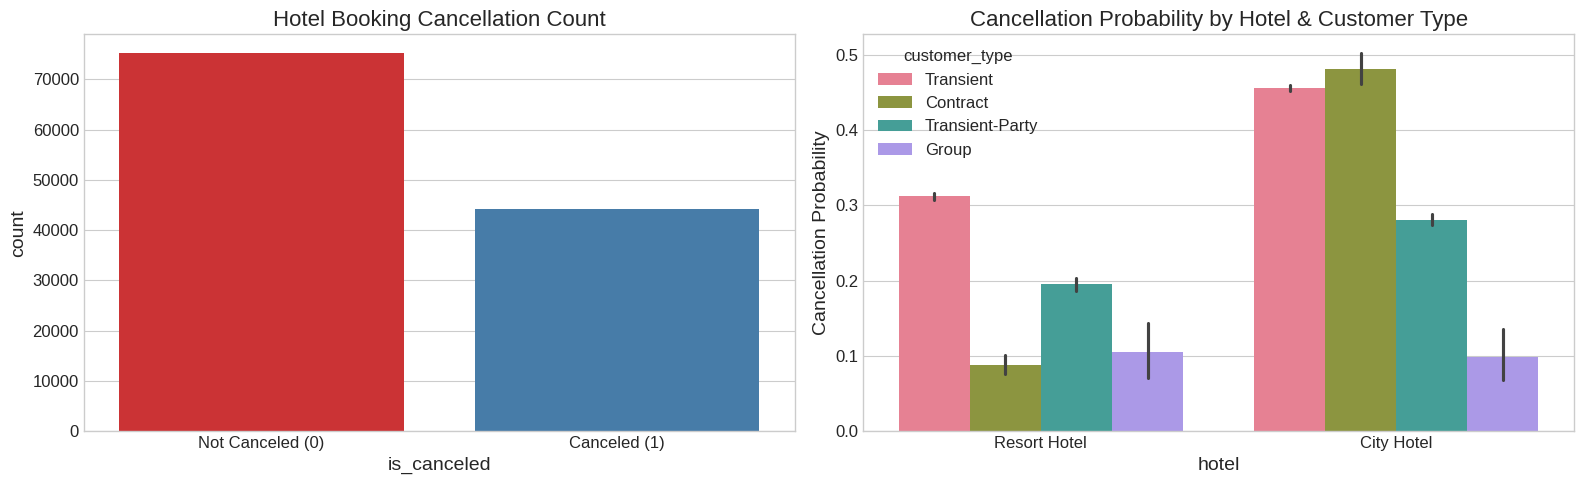

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Count plot of cancellation target class
sns.countplot(data=df, x='is_canceled', palette='Set1', ax=axes[0])
axes[0].set_title('Hotel Booking Cancellation Count')
axes[0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])

# Cancellation rates by Hotel and Customer Type
sns.barplot(data=df, x='hotel', y='is_canceled', hue='customer_type', palette='husl', ax=axes[1])
axes[1].set_title('Cancellation Probability by Hotel & Customer Type')
axes[1].set_ylabel('Cancellation Probability')

plt.tight_layout()
plt.show()

In [ ]:
df = df[(df['adults'] + df['babies'] + df['children']) > 0]

In [ ]:
# Separate features X and target label y
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# Apply train/test split (80-20, Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (95364, 31), Test shape: (23842, 31)


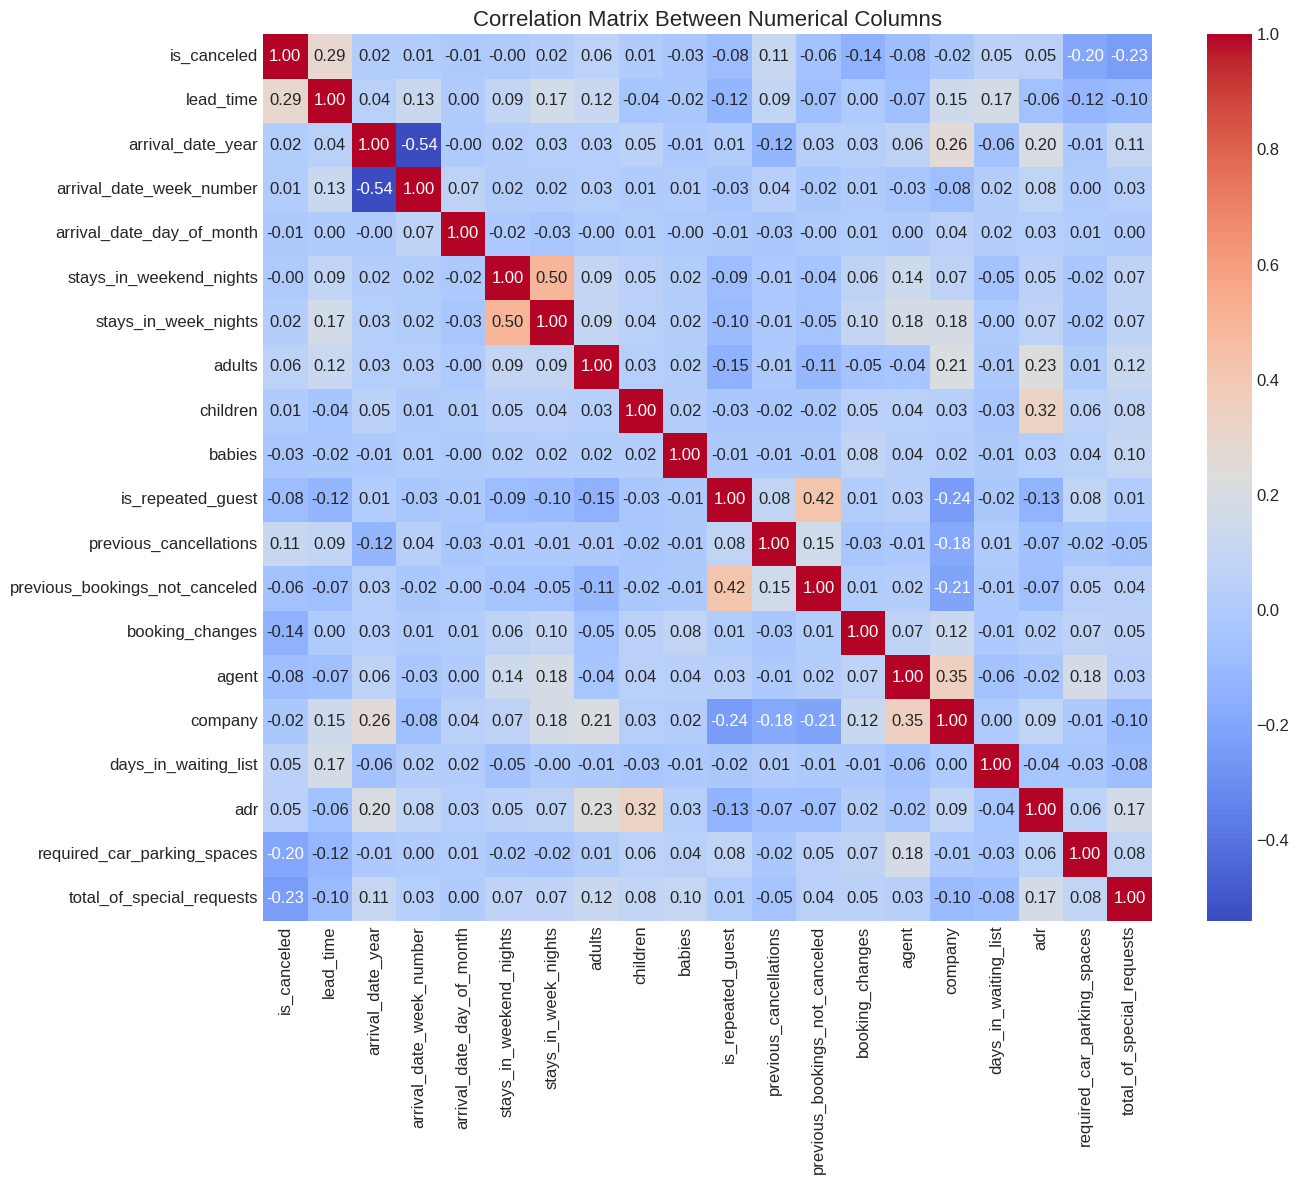

In [49]:

# Correlation Heatmap (numerical variables only)
plt.figure(figsize=(14,12))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Between Numerical Columns')

plt.tight_layout()
plt.show()

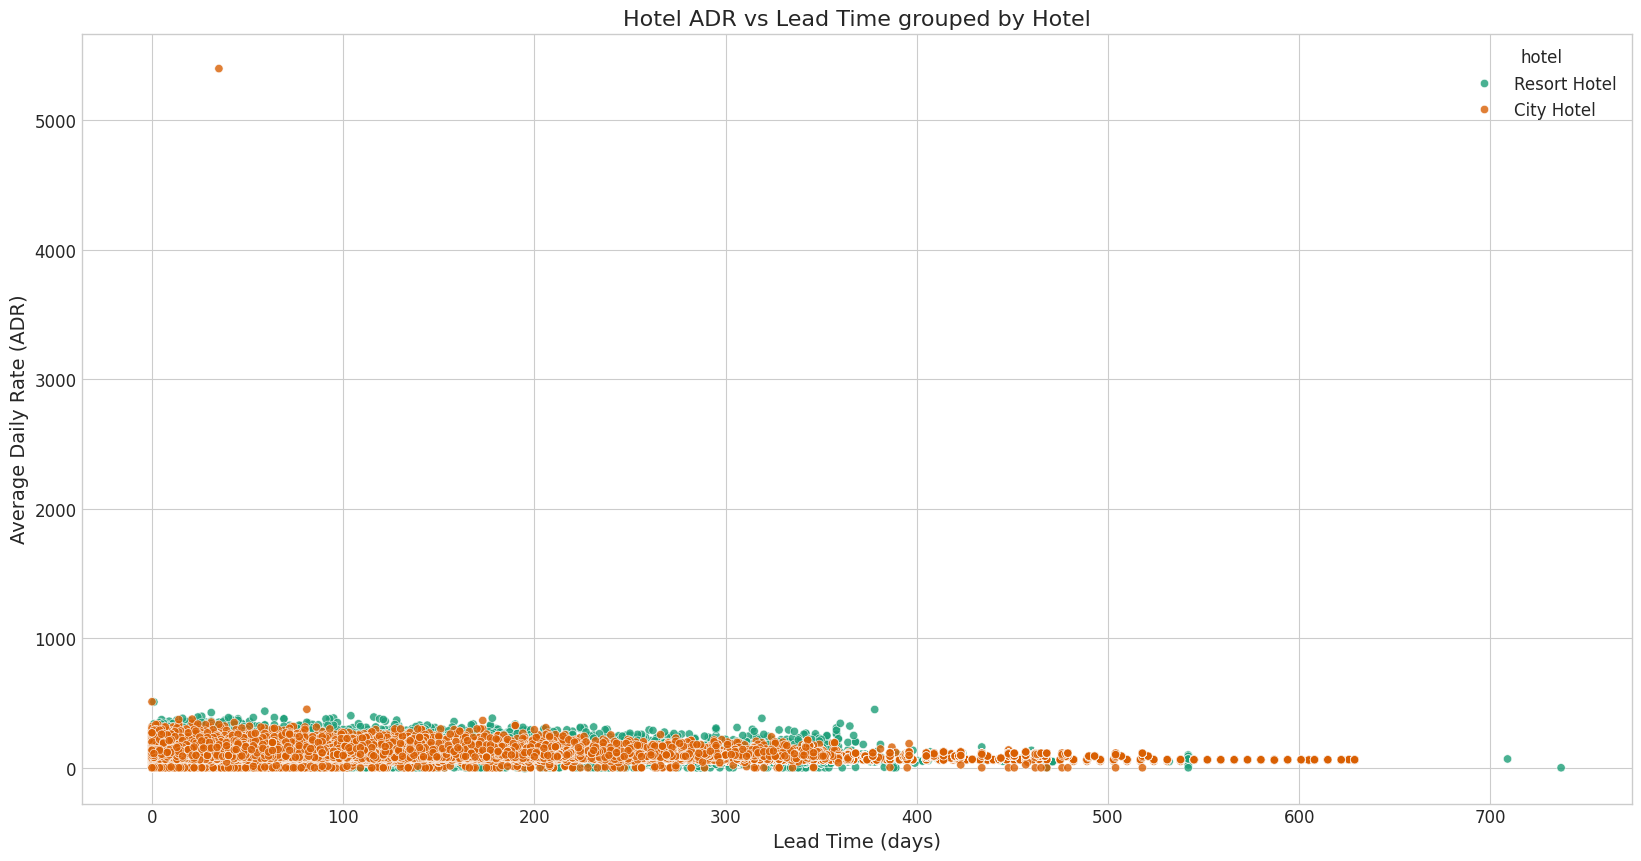

In [ ]:
 ##مش نافعه هشيلها
plt.figure(figsize=(20, 10))

sns.scatterplot(
    data=df,
    x='lead_time',
    y='adr',
    hue='hotel',
    palette='Dark2',
    alpha=0.8
)

plt.title('Hotel ADR vs Lead Time grouped by Hotel')
plt.xlabel('Lead Time (days)')
plt.ylabel('Average Daily Rate (ADR)')

plt.show()

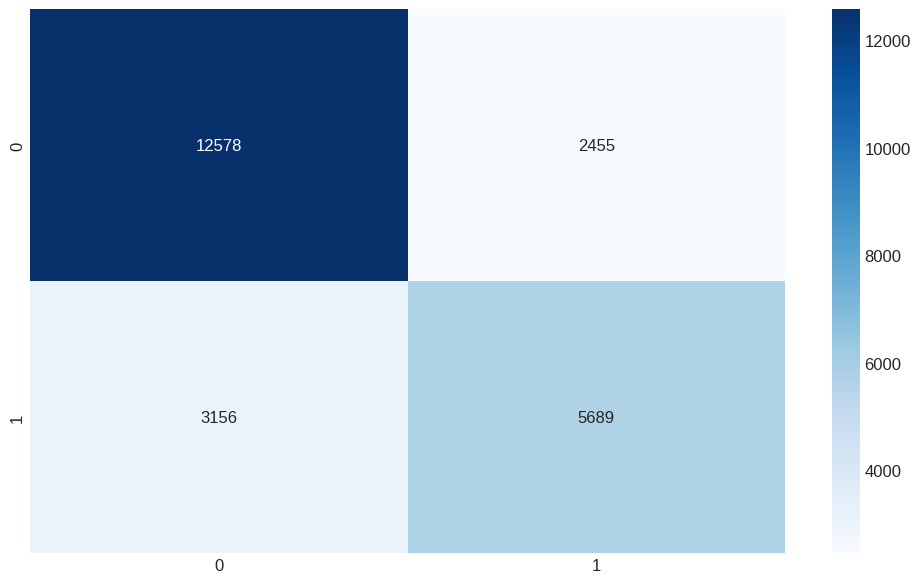

In [50]:
# Select numerical features
X = df[['lead_time', 'adr']]
y = df['is_canceled']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate and retrain the best overall model (Random Forest)
best_name = 'Random Forest'
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)

rf_best.fit(X_train_scaled, y_train)

# Make test predictions
y_pred_best = rf_best.predict(X_test_scaled)


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

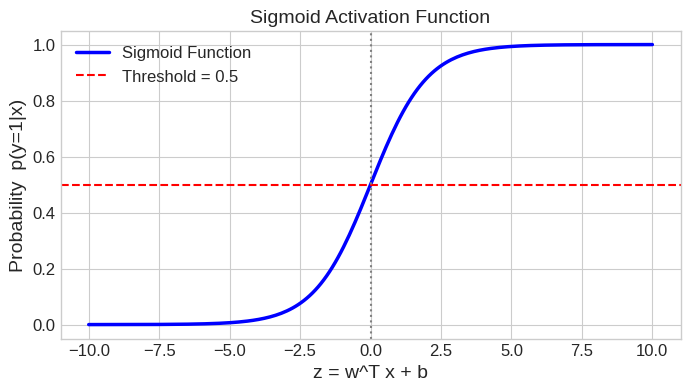

In [37]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 4))
plt.plot(z_values, sigmoid_values, color='blue', linewidth=2.5, label='Sigmoid Function')
plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(0, color='gray', linestyle=':')
plt.title('Sigmoid Activation Function', fontsize=14)
plt.xlabel('z = w^T x + b')
plt.ylabel('Probability  p(y=1|x)')
plt.legend()
plt.show()